In [1]:
import os
import pandas as pd
import subprocess
import re
from tqdm import tqdm
import numpy as np

In [2]:
# load and reset index of df
wt_df = pd.read_pickle('./saved_tables/updated_unmutant_complex_table.pkl').reset_index(drop=True)
wt_df = wt_df[['PDB', 'Receptor Chains', 'Ligand Chains', 'paths', 'affinity']]
wt_df

,PDB,Receptor Chains,Ligand Chains,paths,affinity
0,1A22,B,A,../../PDB/SKEMPI_v2.0/1A22.pdb,12.622671
1,1A4Y,B,A,../../PDB/SKEMPI_v2.0/1A4Y.pdb,20.658646
2,1ACB,I,E,../../PDB/SKEMPI_v2.0/1ACB.pdb,14.567624
3,1AHW,C,"A, B",../../PDB/SKEMPI_v2.0/1AHW.pdb,11.547342
4,1AK4,D,A,../../PDB/SKEMPI_v2.0/1AK4.pdb,6.606704
...,...,...,...,...,...
3093,5E94,"A, B",G,../../PDB/updated_pdb/5E94.pdb,11.621462
3094,5EIV,"A, G, H","I, J, K",../../PDB/updated_pdb/5EIV.pdb,6.203861
3095,5IBK,"A, B",C,../../PDB/updated_pdb/5IBK.pdb,9.756143
3096,6GWC,"A, B",C,../../PDB/updated_pdb/6GWC.pdb,8.956734


In [4]:
wt_df.to_csv('./saved_tables/wt_table.csv', index=False)

# Run US-align for all pdb pairs (too slow, suggest run parallel processors)

In [ ]:
rmsd_matrix = np.zeros((len(wt_df), len(wt_df)))
tmscore_matrix = np.ones((len(wt_df), len(wt_df)))

# Calculate total iterations for progress bar
total_iterations = len(wt_df) * (len(wt_df) - 1)  # exclude diagonal

with tqdm(total=total_iterations, desc="Computing alignments") as pbar:
    for idx in range(len(wt_df)):
        for jdx in range(len(wt_df)):
            if idx == jdx:
                continue
            
            pdb_path1 = wt_df.loc[idx, 'paths']
            pdb_path2 = wt_df.loc[jdx, 'paths']
            
            chain_ids1 = ','.join(list(set([cid.strip() for cid in (wt_df.loc[idx, 'Ligand Chains']+','+wt_df.loc[idx, 'Receptor Chains']).split(',')])))
            chain_ids2 = ','.join(list(set([cid.strip() for cid in (wt_df.loc[jdx, 'Ligand Chains']+','+wt_df.loc[jdx, 'Receptor Chains']).split(',')])))
            
            cmd_line = f'USalign -mol prot -mm 1 -chain1 {chain_ids1} {pdb_path1} -chain2 {chain_ids2} {pdb_path2} -outfmt 1 -a T'
            process = subprocess.Popen(cmd_line, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
            stdout, stderr = process.communicate()
            
            tm_pattern = r'# TM-score=([\d.]+)\s+\(normalized by average length.*?L=([\d.]+)\s+d0=([\d.]+)\)'
            rmsd_pattern = r'# Lali=(\d+)\s+RMSD=([\d.]+)\s+seqID_ali=([\d.]+)'
            output_text = stdout.decode('utf-8')
            
            tm_match = re.search(tm_pattern, output_text)
            rmsd_match = re.search(rmsd_pattern, output_text)
            
            if tm_match and rmsd_match:
                tmscore_matrix[idx, jdx] = float(tm_match.group(1))
                rmsd_matrix[idx, jdx] = float(rmsd_match.group(2))
            else:
                # Handle cases where parsing fails
                tmscore_matrix[idx, jdx] = np.nan
                rmsd_matrix[idx, jdx] = np.nan
            
            # Update progress bar
            pbar.update(1)
            pbar.set_postfix({'idx': idx, 'jdx': jdx, 'TM': f'{tmscore_matrix[idx, jdx]:.3f}', 'RMSD': f'{rmsd_matrix[idx, jdx]:.2f}'})

print("Done!")
print(f"TM-score matrix shape: {tmscore_matrix.shape}")
print(f"RMSD matrix shape: {rmsd_matrix.shape}")
np.save('../../GraPPI_data/wt_rmsd_matrix.npy', rmsd_matrix)
np.save('../../GraPPI_data/wt_tmscore_matrix.npy', tmscore_matrix)

# Structural Clustering

In [ ]:
wt_tmscore = np.load('../../GraPPI_data/wt_tmscore_matrix.npy')
wt_rmsd = np.load('../../GraPPI_data/wt_rmsd_matrix.npy')
up_tmscore = np.load('../../GraPPI_data/updated_wt_tmscore_matrix.npy')
up_rmsd = np.load('../../GraPPI_data/updated_wt_rmsd_matrix.npy')

# pad zeros for wt_tmscore to match up_tmscore shape
padded_wt_tmscore = np.ones_like(up_tmscore)
padded_wt_tmscore[:wt_tmscore.shape[0], :wt_tmscore.shape[1]] = wt_tmscore
tmscore = padded_wt_tmscore
# pad zeros for wt_rmsd to match up_tmscore shape
padded_wt_rmsd = np.zeros_like(up_rmsd)
padded_wt_rmsd[:wt_rmsd.shape[0], :wt_rmsd.shape[1]] = wt_rmsd
rmsd = padded_wt_rmsd

tmscore = tmscore + up_tmscore - 1
rmsd = rmsd + up_rmsd - np.diag(up_rmsd.diagonal())

tmscore = tmscore + tmscore.T - 1
rmsd = rmsd + rmsd.T - np.diag(rmsd.diagonal())

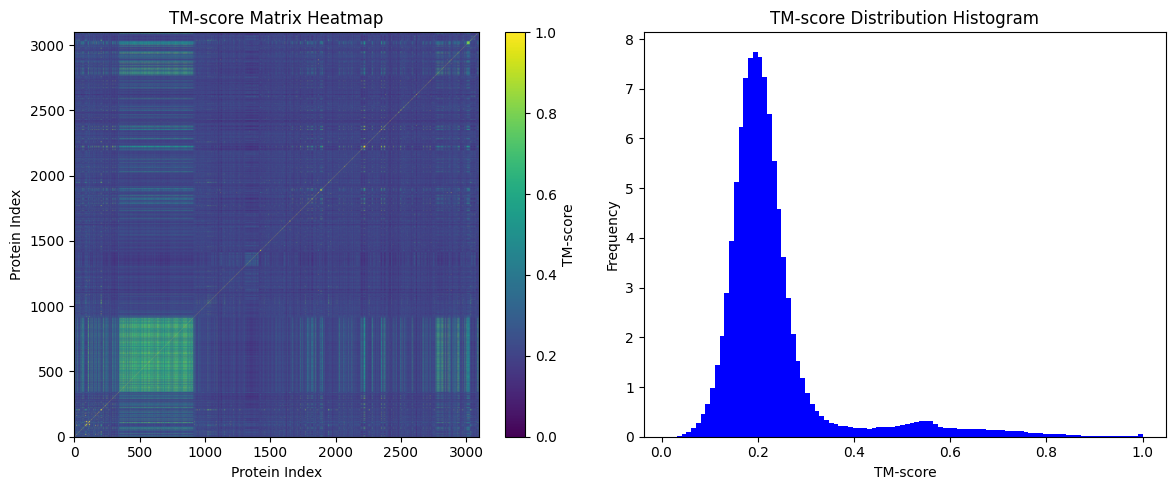

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(12, 5))
im0 = ax[0].imshow(tmscore, cmap='viridis', vmin=0, vmax=1, origin='lower')
fig.colorbar(im0, ax=ax[0], label='TM-score')
ax[0].set_title('TM-score Matrix Heatmap')
ax[0].set_xlabel('Protein Index')
ax[0].set_ylabel('Protein Index')
ax[1].hist(tmscore.flatten(), bins=100, color='blue', density=True)
ax[1].set_title('TM-score Distribution Histogram')
ax[1].set_xlabel('TM-score')
ax[1].set_ylabel('Frequency')
plt.tight_layout()

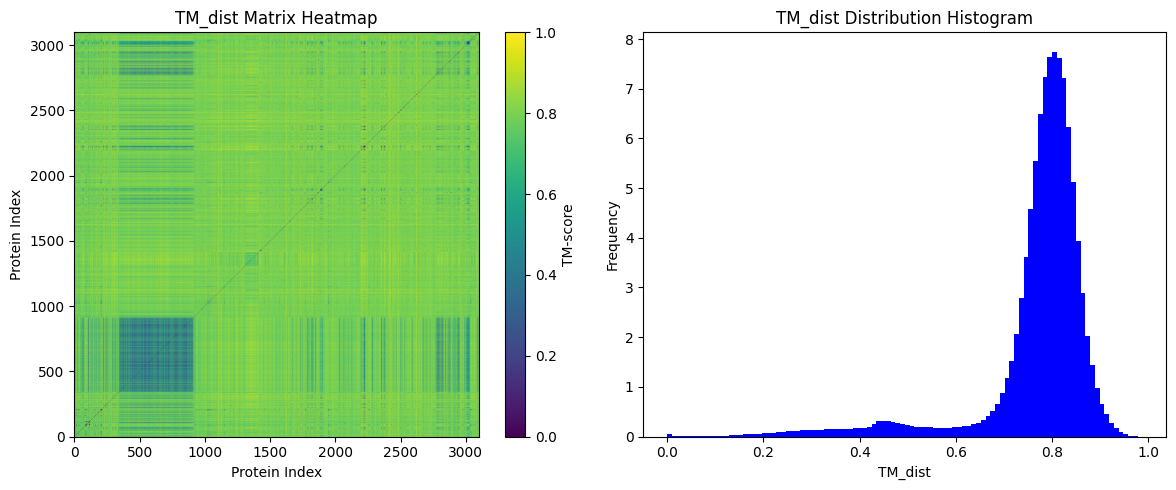

In [5]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
tm_dist = 1 - tmscore
im0 = ax[0].imshow(tm_dist, cmap='viridis', vmin=0, vmax=1, origin='lower')
fig.colorbar(im0, ax=ax[0], label='TM-score')
ax[0].set_title('TM_dist Matrix Heatmap')
ax[0].set_xlabel('Protein Index')
ax[0].set_ylabel('Protein Index')
ax[1].hist(tm_dist.flatten(), bins=100, color='blue', density=True)
ax[1].set_title('TM_dist Distribution Histogram')
ax[1].set_xlabel('TM_dist')
ax[1].set_ylabel('Frequency')
plt.tight_layout()

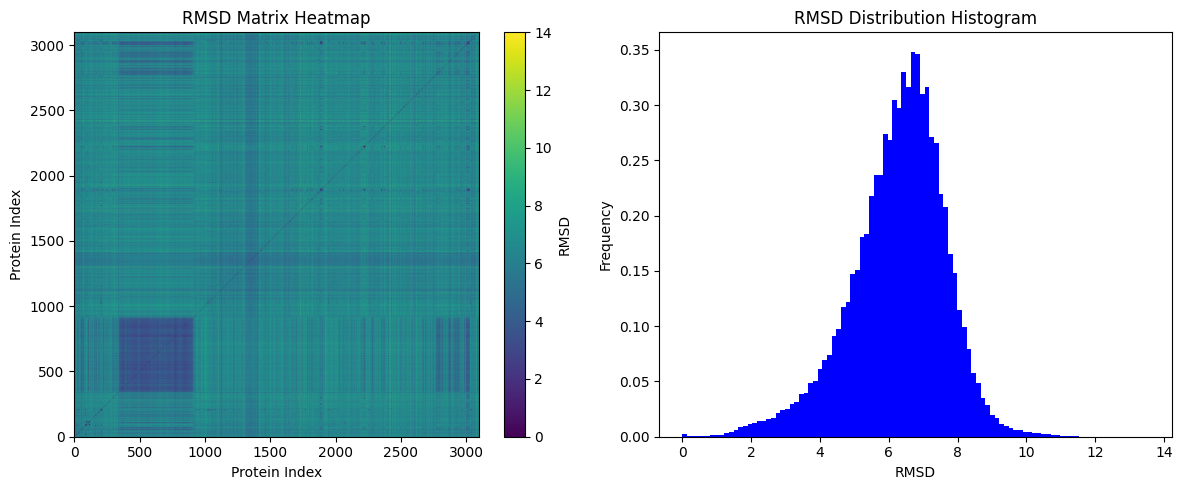

In [6]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
im0 = ax[0].imshow(rmsd, cmap='viridis', vmin=0, vmax=14, origin='lower')
fig.colorbar(im0, ax=ax[0], label='RMSD')
ax[0].set_title('RMSD Matrix Heatmap')
ax[0].set_xlabel('Protein Index')
ax[0].set_ylabel('Protein Index')
ax[1].hist(rmsd.flatten(), bins=100, color='blue', density=True)
ax[1].set_title('RMSD Distribution Histogram')
ax[1].set_xlabel('RMSD')
ax[1].set_ylabel('Frequency')
plt.tight_layout()

In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
# Create combined distance metric
# Normalize RMSD to [0,1] range first
rmsd_norm = rmsd #(rmsd - rmsd.min()) / (rmsd.max() - rmsd.min())
tm_dist = 1 - tmscore

# Weighted combination (adjust weights as needed)
alpha = 1  # Weight for TM-score
beta = 0  # Weight for RMSD
combined_distance = alpha * tm_dist + beta * rmsd_norm

# Method 1: Hierarchical on combined distance
from scipy.spatial.distance import squareform
condensed = squareform(combined_distance, checks=False)
Z = linkage(condensed, method='average')

check_cluster = 0.65 #60 # or 0.6
if check_cluster > 1 and int(check_cluster) == check_cluster:
    n_clusters = check_cluster
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')  # Use 'maxclust' instead of 'distance'
else:
    threshold = check_cluster
    clusters = fcluster(Z, t=threshold, criterion='distance')

print(f"Number of clusters: {len(set(clusters))}")
print(f"Cluster sizes:\n{pd.Series(clusters).value_counts().sort_index()}")

# Add cluster assignments to dataframe
wt_df['cluster'] = clusters

# Find representative structure for each cluster
representatives = []
n_clusters = len(set(clusters))
for cluster_id in range(1, n_clusters + 1):
    # Get all structures in this cluster
    cluster_mask = (clusters == cluster_id)
    cluster_indices = np.where(cluster_mask)[0]
    
    if len(cluster_indices) == 0:
        continue
    
    # Method 1: Choose structure with minimum average distance to all others in cluster
    # (medoid - most central structure)
    cluster_distances = combined_distance[cluster_mask][:, cluster_mask]
    avg_distances = cluster_distances.mean(axis=1)
    medoid_idx_within_cluster = avg_distances.argmin()
    medoid_idx = cluster_indices[medoid_idx_within_cluster]
    
    representatives.append({
        'cluster_id': cluster_id,
        'index': medoid_idx,
        'pdb_id': wt_df.loc[medoid_idx, 'PDB'],
        'cluster_size': len(cluster_indices),
        'avg_dist_to_cluster': avg_distances[medoid_idx_within_cluster]
    })

representatives_df = pd.DataFrame(representatives)

Number of clusters: 469
Cluster sizes:
1      1
2      1
3      2
4      1
5      1
      ..
465    1
466    1
467    1
468    1
469    1
Name: count, Length: 469, dtype: int64


Text(0, 0.5, 'TM Distance')

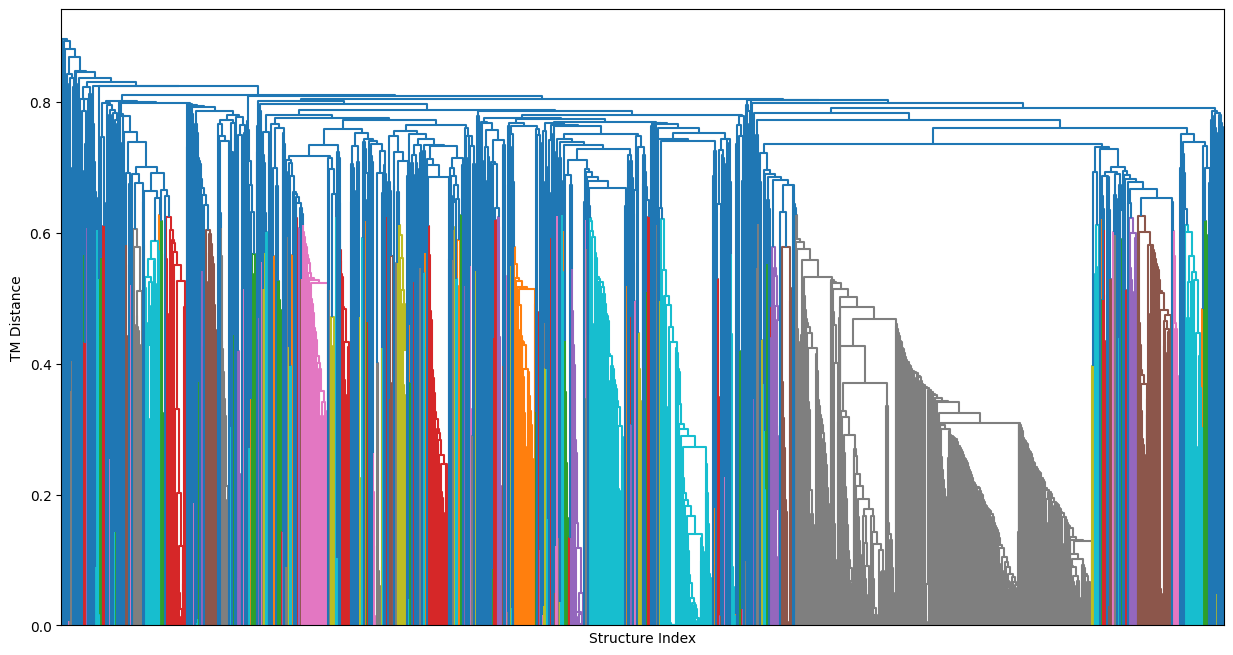

In [9]:
plt.figure(figsize=(15, 8))
dendrogram(Z, no_labels=True)
plt.xlabel('Structure Index')
plt.ylabel('TM Distance')

In [15]:
representatives_df.sort_values(by='cluster_size', ascending=False)

,cluster_id,index,pdb_id,cluster_size,avg_dist_to_cluster
409,410,845,2HRP,796,0.305063
354,355,1712,3L33,145,0.251046
327,328,1730,3MJH,99,0.398333
425,426,833,2P4A,91,0.478831
172,173,1402,2MRO,86,0.440837
...,...,...,...,...,...
464,465,2863,6JHW,1,0.000000
465,466,994,1KKL,1,0.000000
466,467,1004,2B4J,1,0.000000
467,468,2937,6DLD,1,0.000000


In [16]:
representatives_df.to_pickle('./saved_tables/wt_cluster_representatives.pkl')

# Get representing complexes' sequence

In [3]:
representatives_df = pd.read_pickle('./saved_tables/wt_cluster_representatives.pkl')
selected_wt_df = wt_df.loc[representatives_df['index']].reset_index(drop=True).drop(columns=['KD(M)'])
selected_wt_df

,PDB,paths,affinity,Ligand Chains,Receptor Chains
0,3HUG,../../PDB/PDBbind_v2020/3hug.pdb,10.498013,"A, C, E, G, I, K, M, O, Q, S","B, D, F, H, J, L, N, P, R, T"
1,5D50,../../PDB/PDBbind_v2020/5d50.pdb,7.615523,"E, F, G, H","A, B, C, D"
2,3VR6,../../PDB/SKEMPI_v2.0/3VR6.pdb,11.993716,"A, B, C, D, E, F","G, H"
3,5THP,../../PDB/PDBbind_v2020/5thp.pdb,13.196241,"C, F, I, L, O, R","A, B, D, E, G, H, J, K, M, N, P, Q"
4,2IOU,../../PDB/PDBbind_v2020/2iou.pdb,7.444592,"G, H","A, B, C, D, E, F"
...,...,...,...,...,...
464,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C"
465,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H
466,2B4J,../../PDB/Affinity_Benchmark_v5.5/2B4J.pdb,10.852044,"A, B",C
467,6DLD,../../PDB/PDBbind_v2020/6dld.pdb,13.117165,"B, D","A, C"


In [4]:
# filter out rows Ligand Chains or Receptor Chains have over 3 letters
def filter_chain_length(row):
    ligand_chains = [cid.strip() for cid in row['Ligand Chains'].split(',')]
    receptor_chains = [cid.strip() for cid in row['Receptor Chains'].split(',')]
    if len(ligand_chains) > 3 or len(receptor_chains) > 3:
        return False
    else:
        return True
selected_wt_df = selected_wt_df[selected_wt_df.apply(filter_chain_length, axis=1)].reset_index(drop=True)
selected_wt_df

,PDB,paths,affinity,Ligand Chains,Receptor Chains
0,1Q68,../../PDB/PDBbind_v2020/1q68.pdb,8.723979,B,A
1,1DE4,../../PDB/Affinity_Benchmark_v5.5/1DE4.pdb,9.773309,"A, B","C, F"
2,6O8B,../../PDB/PDBbind_v2020/6o8b.pdb,6.761362,"D, E","A, B"
3,3NOC,../../PDB/PDBbind_v2020/3noc.pdb,12.031935,"D, E","A, B, C"
4,2NUP,../../PDB/PDBbind_v2020/2nup.pdb,6.817803,C,"A, B"
...,...,...,...,...,...
434,5J4A,../../PDB/PDBbind_v2020/5j4a.pdb,9.739460,"B, D","A, C"
435,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C"
436,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H
437,2B4J,../../PDB/Affinity_Benchmark_v5.5/2B4J.pdb,10.852044,"A, B",C


In [5]:
from Bio.PDB import PDBParser
tqdm.pandas()
def check_chain_lengths(row, min_length=12, max_length=1000):
    """
    Check if all ligand and receptor chains have at least min_length residues.
    Returns True if all chains are long enough, False otherwise.
    """
    parser = PDBParser(QUIET=True)
    pdb_path = row['paths']
    
    try:
        structure = parser.get_structure('pdb', pdb_path)
        model = next(structure.get_models())
        
        # Get chain IDs
        ligand_chain_ids = [cid.strip() for cid in row['Ligand Chains'].split(',')]
        receptor_chain_ids = [cid.strip() for cid in row['Receptor Chains'].split(',')]
        total_residues = 0
        # Check ligand chains
        for chain_id in ligand_chain_ids:
            if chain_id in model:
                chain = model[chain_id]
                # Count residues (excluding hetero atoms)
                residue_count = sum(1 for res in chain if res.id[0] == ' ')
                total_residues += residue_count
                if residue_count < min_length:
                    return False
        
        # Check receptor chains
        for chain_id in receptor_chain_ids:
            if chain_id in model:
                chain = model[chain_id]
                # Count residues (excluding hetero atoms)
                residue_count = sum(1 for res in chain if res.id[0] == ' ')
                total_residues += residue_count
                if residue_count < min_length:
                    return False
        if total_residues > max_length:
            return False
        return True
    
    except Exception as e:
        print(f"Error processing {row['PDB']}: {e}")
        return False

# Apply filter
print(f"Before filtering: {len(selected_wt_df)} rows")
selected_wt_df = selected_wt_df[selected_wt_df.progress_apply(check_chain_lengths, axis=1)].reset_index(drop=True)
print(f"After filtering: {len(selected_wt_df)} rows")
print(f"Removed: {len(selected_wt_df) - len(selected_wt_df)} rows with chains ≤9 but >1000 residues")

selected_wt_df

Before filtering: 439 rows


100%|██████████| 439/439 [00:35<00:00, 12.47it/s]


After filtering: 385 rows
Removed: 0 rows with chains ≤9 but >1000 residues


,PDB,paths,affinity,Ligand Chains,Receptor Chains
0,1Q68,../../PDB/PDBbind_v2020/1q68.pdb,8.723979,B,A
1,3H2U,../../PDB/PDBbind_v2020/3h2u.pdb,6.680942,"A, C","B, D"
2,4R8G,../../PDB/PDBbind_v2020/4r8g.pdb,8.603800,"A, B, H",E
3,3Q4F,../../PDB/PDBbind_v2020/3q4f.pdb,7.345796,"G, H","A, B"
4,4G59,../../PDB/PDBbind_v2020/4g59.pdb,8.695086,"A, B","C, D"
...,...,...,...,...,...
380,5OC7,../../PDB/PDBbind_v2020/5oc7.pdb,10.201460,"B, C","A, D"
381,5J4A,../../PDB/PDBbind_v2020/5j4a.pdb,9.739460,"B, D","A, C"
382,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C"
383,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H


In [6]:
from Bio.PDB import PDBParser, PPBuilder
parser = PDBParser(QUIET=True)
ppb = PPBuilder()
# fallback 3->1 map for any non-standard case
aa3to1 = {
    'ALA':'A','CYS':'C','ASP':'D','GLU':'E','PHE':'F','GLY':'G','HIS':'H','ILE':'I',
    'LYS':'K','LEU':'L','MET':'M','ASN':'N','PRO':'P','GLN':'Q','ARG':'R','SER':'S',
    'THR':'T','VAL':'V','TRP':'W','TYR':'Y',
    # common alternates
    'MSE':'M','SEC':'U','PYL':'O','HSD':'H','HSE':'H','HSP':'H'
}
def seq_from_chain(chain):
    """Return sequence string for a Bio.PDB chain (use PPBuilder, fallback to manual mapping)."""
    peptides = ppb.build_peptides(chain)
    if peptides:
        seq_parts = [str(p.get_sequence()) for p in peptides]
        seq = ''.join(seq_parts)
        if seq:
            return seq
    # fallback: iterate residues and map three-letter codes
    seq_chars = []
    for res in chain:
        # ignore hetero residues and insertion-only ids
        if res.id[0] != ' ':
            continue
        three = res.get_resname().upper()
        one = aa3to1.get(three, 'X')  # unknown -> X
        seq_chars.append(one)
    return ''.join(seq_chars)
def extract_sequences_and_chainmap(pdb_path:str, rc_ids:str, lg_ids:str,base_dir:str):
    # Resolve path
    if base_dir and not os.path.isabs(pdb_path):
        full_path = os.path.join(base_dir, pdb_path)
    else:
        full_path = pdb_path
    full_path = os.path.abspath(full_path)
    structure = parser.get_structure('pdb', full_path)
    # Use first model (typical)
    model = next(structure.get_models())
    rc_seq_list = []
    lg_seq_list = []
    # Build sequences in the order of appearance
    for ch in model.get_chains():
        seq = seq_from_chain(ch)
        if ch.id in rc_ids:
            rc_seq_list.append(seq)
        if ch.id in lg_ids:
            lg_seq_list.append(seq)
    joined_rc_seq = ':'.join(rc_seq_list)
    joined_lg_seq = ':'.join(lg_seq_list)
    return joined_rc_seq, joined_lg_seq

In [7]:
rc_seqs= []
lg_seqs = []
new_receptor_chains = []
new_ligand_chains = []
base_dir=''

for idx, row in tqdm(selected_wt_df.iterrows(), total=len(selected_wt_df), desc='Extracting sequences'):
    pdb_path = row.get('paths', None)
    rc_ids = row.get('Receptor Chains','')
    lg_ids = row.get('Ligand Chains','')
    rc_seq, lg_seq = extract_sequences_and_chainmap(pdb_path, rc_ids, lg_ids, base_dir=base_dir)
    rc_seqs.append(rc_seq)
    lg_seqs.append(lg_seq)

selected_wt_df['Receptor Sequences'] = rc_seqs
selected_wt_df['Ligand Sequences'] = lg_seqs
selected_wt_df

Extracting sequences: 100%|██████████| 385/385 [00:28<00:00, 13.56it/s]


,PDB,paths,affinity,Ligand Chains,Receptor Chains,Receptor Sequences,Ligand Sequences
0,1Q68,../../PDB/PDBbind_v2020/1q68.pdb,8.723979,B,A,RCRHRRRQAERLSQIKRLLSEKKTCQCPHRFQKTCSPI,SHPEDDWLENIDVCENCHYPIVPLDGKGT
1,3H2U,../../PDB/PDBbind_v2020/3h2u.pdb,6.680942,"A, C","B, D",LDPEEIRKRLEHTERQFRNRRKILIRGLPGDVTNQEVHDLLSDYEL...,DEEFPEQKAGEVINQPMMMAARQLHDEARKWSSKGNDIIAAAKRMA...
2,4R8G,../../PDB/PDBbind_v2020/4r8g.pdb,8.603800,"A, B, H",E,RRQSLATKIQAAWRGFHWRQKFLRVKRSAICIQSWWRGTLGRRKAA...,QLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAEL...
3,3Q4F,../../PDB/PDBbind_v2020/3q4f.pdb,7.345796,"G, H","A, B",MEELEQGLLMQPWAWLQLAENSLLAKVFITKQGYALLVSDLQQVWH...,MERKISRIHLVSEPSITHFLQVSWEKTLESGFVITLTDGHSAWTGT...
4,4G59,../../PDB/PDBbind_v2020/4g59.pdb,8.695086,"A, B","C, D",SYMDVRIFEDERVDICQDLTATFISYREGPEMFRHSINLEQSSDIF...,AHSLRCNLTIKAPTPADPLWYEAKCLVDEILILHLSNINKANATEV...
...,...,...,...,...,...,...,...
380,5OC7,../../PDB/PDBbind_v2020/5oc7.pdb,10.201460,"B, C","A, D",RQLLKDSFMVELVEGARKLRHVFLFTDLLLCTKLKQYDCKWYIPLT...,GSVSSVPTKLEVVAATPTSLLISWDAPAVTVVFYVITYGETGGNSP...
381,5J4A,../../PDB/PDBbind_v2020/5j4a.pdb,9.739460,"B, D","A, C",RPGEAGAAAELENYLGGTLQRAPQGSSVDFVFSSGPNNGKTVDFML...,AGSIVISKEVRVPVSTSQFDYLVSRIGDQFHSSDMWIKDEVYLPME...
382,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C",AFKRAIIFTSFNGFEKVSRTEKRRLAKIINARVSIIDEYLRAKDTN...,GEIEKRQEENRKDREKAAAKFREYFPNFVGEPKSKDILKLRLYEQQ...
383,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H,QKTFKVTADSGIHARPATVLVQTASKYDADVNLEYNGKTVNLKSIM...,ERRSMHGVLVDIYGLGVLITGDSGVGKSETALELVQRGHRLIADDR...


In [21]:
selected_wt_df.to_pickle('./saved_tables/wt_cluster_repre_seqs_table.pkl')
#selected_wt_df = pd.read_pickle('./saved_tables/wt_cluster_repre_seqs_table.pkl')

In [8]:
selected_wt_df

,PDB,paths,affinity,Ligand Chains,Receptor Chains,Receptor Sequences,Ligand Sequences
0,1Q68,../../PDB/PDBbind_v2020/1q68.pdb,8.723979,B,A,RCRHRRRQAERLSQIKRLLSEKKTCQCPHRFQKTCSPI,SHPEDDWLENIDVCENCHYPIVPLDGKGT
1,3H2U,../../PDB/PDBbind_v2020/3h2u.pdb,6.680942,"A, C","B, D",LDPEEIRKRLEHTERQFRNRRKILIRGLPGDVTNQEVHDLLSDYEL...,DEEFPEQKAGEVINQPMMMAARQLHDEARKWSSKGNDIIAAAKRMA...
2,4R8G,../../PDB/PDBbind_v2020/4r8g.pdb,8.603800,"A, B, H",E,RRQSLATKIQAAWRGFHWRQKFLRVKRSAICIQSWWRGTLGRRKAA...,QLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAEL...
3,3Q4F,../../PDB/PDBbind_v2020/3q4f.pdb,7.345796,"G, H","A, B",MEELEQGLLMQPWAWLQLAENSLLAKVFITKQGYALLVSDLQQVWH...,MERKISRIHLVSEPSITHFLQVSWEKTLESGFVITLTDGHSAWTGT...
4,4G59,../../PDB/PDBbind_v2020/4g59.pdb,8.695086,"A, B","C, D",SYMDVRIFEDERVDICQDLTATFISYREGPEMFRHSINLEQSSDIF...,AHSLRCNLTIKAPTPADPLWYEAKCLVDEILILHLSNINKANATEV...
...,...,...,...,...,...,...,...
380,5OC7,../../PDB/PDBbind_v2020/5oc7.pdb,10.201460,"B, C","A, D",RQLLKDSFMVELVEGARKLRHVFLFTDLLLCTKLKQYDCKWYIPLT...,GSVSSVPTKLEVVAATPTSLLISWDAPAVTVVFYVITYGETGGNSP...
381,5J4A,../../PDB/PDBbind_v2020/5j4a.pdb,9.739460,"B, D","A, C",RPGEAGAAAELENYLGGTLQRAPQGSSVDFVFSSGPNNGKTVDFML...,AGSIVISKEVRVPVSTSQFDYLVSRIGDQFHSSDMWIKDEVYLPME...
382,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C",AFKRAIIFTSFNGFEKVSRTEKRRLAKIINARVSIIDEYLRAKDTN...,GEIEKRQEENRKDREKAAAKFREYFPNFVGEPKSKDILKLRLYEQQ...
383,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H,QKTFKVTADSGIHARPATVLVQTASKYDADVNLEYNGKTVNLKSIM...,ERRSMHGVLVDIYGLGVLITGDSGVGKSETALELVQRGHRLIADDR...


Calculating sequence lengths: 100%|██████████| 385/385 [00:00<00:00, 77593.92it/s]


Text(0, 0.5, 'Frequency')

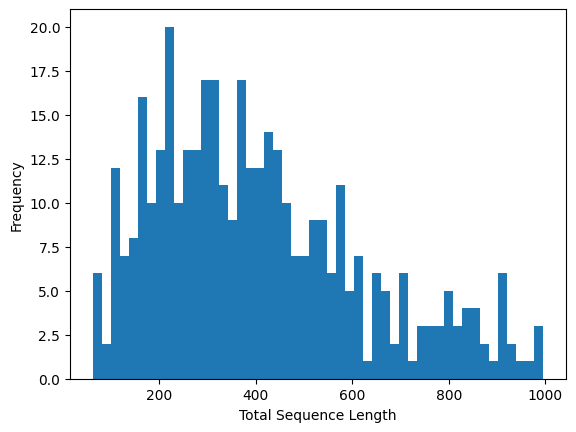

In [10]:
import matplotlib.pyplot as plt
seq_lens = []
for idx, row in tqdm(selected_wt_df.iterrows(), total=len(selected_wt_df), desc='Calculating sequence lengths'):
    rc_seq = row['Receptor Sequences']
    lg_seq = row['Ligand Sequences']
    total_len = sum(len(part) for part in rc_seq.split(':')) + sum(len(part) for part in lg_seq.split(':'))
    seq_lens.append(total_len)
plt.hist(seq_lens, bins=50)
plt.xlabel('Total Sequence Length')
plt.ylabel('Frequency')

# Balanced Random Pairing (Each row selected similar times)

In [5]:
selected_wt_df = pd.read_pickle('./saved_tables/wt_cluster_repre_seqs_table.pkl')

Generating perfectly balanced pairings...

Receptor partner selection frequencies:
Mean: 4.00
Std: 0.19
Min: 3
Max: 5
Target: 4
Samples with exactly 4 selections: 371/385

Ligand partner selection frequencies:
Mean: 4.00
Std: 0.18
Min: 3
Max: 5
Target: 4
Samples with exactly 4 selections: 373/385

Receptor partner count distribution:
3      7
4    371
5      7
Name: count, dtype: int64

Ligand partner count distribution:
3      6
4    373
5      6
Name: count, dtype: int64


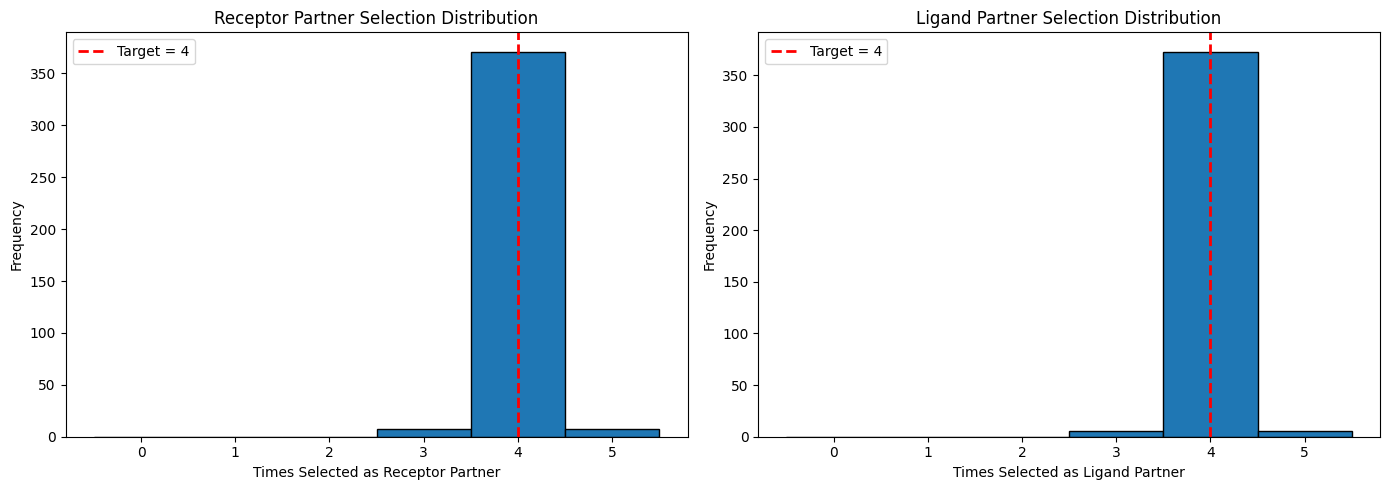

In [ ]:
seed = 30
import matplotlib.pyplot as plt
fasta_per_len = 80
root_path1 = 'swap_pp_by_AF0/input/'
root_path2 = 'swap_pp_by_AF1/input/'
root_path3 = 'swap_pp_by_AF2/input/'
root_path4 = 'swap_pp_by_AF3/input/'

n_samples = len(selected_wt_df)
pairs_per_sample = 4

# Create perfectly balanced pairings where each index appears exactly 5 times
def create_balanced_pairings(n_samples, pairs_per_sample, seed):
    """
    Create balanced pairings where each sample is selected exactly pairs_per_sample times.
    """
    np.random.seed(seed)
    
    # Create a list where each index appears exactly pairs_per_sample times
    partner_pool = []
    for idx in range(n_samples):
        partner_pool.extend([idx] * pairs_per_sample)
    
    # Shuffle the pool
    np.random.shuffle(partner_pool)
    
    # Assign partners to each sample
    pairings = {}
    pool_idx = 0
    
    for i in range(n_samples):
        partners = []
        attempts = 0
        max_attempts = 1000
        
        while len(partners) < pairs_per_sample and attempts < max_attempts:
            if pool_idx >= len(partner_pool):
                # Reshuffle if we run out
                np.random.shuffle(partner_pool)
                pool_idx = 0
            
            candidate = partner_pool[pool_idx]
            pool_idx += 1
            
            # Check if candidate is valid (not self, not already selected)
            if candidate != i and candidate not in partners:
                partners.append(candidate)
            
            attempts += 1
        
        if len(partners) < pairs_per_sample:
            # Fallback: fill with random valid choices
            available = [idx for idx in range(n_samples) if idx != i and idx not in partners]
            needed = pairs_per_sample - len(partners)
            if len(available) >= needed:
                partners.extend(np.random.choice(available, size=needed, replace=False))
        
        pairings[i] = partners[:pairs_per_sample]
    
    return pairings

# Generate balanced pairings
print("Generating perfectly balanced pairings...")
receptor_pairs = create_balanced_pairings(n_samples, pairs_per_sample, seed=seed)
ligand_pairs = create_balanced_pairings(n_samples, pairs_per_sample, seed=seed+1)

# Verify the distribution
receptor_partner_counts = {i: 0 for i in range(n_samples)}
ligand_partner_counts = {i: 0 for i in range(n_samples)}

for i in range(n_samples):
    for j in receptor_pairs[i]:
        receptor_partner_counts[j] += 1
    for j in ligand_pairs[i]:
        ligand_partner_counts[j] += 1

# Print statistics
print("\n" + "=" * 60)
print("Receptor partner selection frequencies:")
print(f"Mean: {np.mean(list(receptor_partner_counts.values())):.2f}")
print(f"Std: {np.std(list(receptor_partner_counts.values())):.2f}")
print(f"Min: {np.min(list(receptor_partner_counts.values()))}")
print(f"Max: {np.max(list(receptor_partner_counts.values()))}")
print(f"Target: {pairs_per_sample}")
print(f"Samples with exactly {pairs_per_sample} selections: {sum(1 for v in receptor_partner_counts.values() if v == pairs_per_sample)}/{n_samples}")

print("\nLigand partner selection frequencies:")
print(f"Mean: {np.mean(list(ligand_partner_counts.values())):.2f}")
print(f"Std: {np.std(list(ligand_partner_counts.values())):.2f}")
print(f"Min: {np.min(list(ligand_partner_counts.values()))}")
print(f"Max: {np.max(list(ligand_partner_counts.values()))}")
print(f"Target: {pairs_per_sample}")
print(f"Samples with exactly {pairs_per_sample} selections: {sum(1 for v in ligand_partner_counts.values() if v == pairs_per_sample)}/{n_samples}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(list(receptor_partner_counts.values()), bins=range(0, max(receptor_partner_counts.values())+2), 
             edgecolor='black', align='left')
axes[0].axvline(pairs_per_sample, color='red', linestyle='--', linewidth=2, label=f'Target = {pairs_per_sample}')
axes[0].set_xlabel('Times Selected as Receptor Partner')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Receptor Partner Selection Distribution')
axes[0].legend()

axes[1].hist(list(ligand_partner_counts.values()), bins=range(0, max(ligand_partner_counts.values())+2), 
             edgecolor='black', align='left')
axes[1].axvline(pairs_per_sample, color='red', linestyle='--', linewidth=2, label=f'Target = {pairs_per_sample}')
axes[1].set_xlabel('Times Selected as Ligand Partner')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Ligand Partner Selection Distribution')
axes[1].legend()

plt.tight_layout()

# Show the actual distribution values
print("\n" + "=" * 60)
print("Receptor partner count distribution:")
print(pd.Series(receptor_partner_counts.values()).value_counts().sort_index())
print("\nLigand partner count distribution:")
print(pd.Series(ligand_partner_counts.values()).value_counts().sort_index())

In [7]:
receptor_pairs

{0: [31, 68, 29, 139],
 1: [268, 302, 95, 66],
 2: [73, 77, 45, 311],
 3: [258, 187, 128, 154],
 4: [0, 347, 63, 236],
 5: [294, 334, 349, 109],
 6: [7, 223, 311, 377],
 7: [382, 288, 231, 204],
 8: [248, 320, 255, 321],
 9: [296, 303, 23, 120],
 10: [234, 93, 174, 185],
 11: [176, 259, 322, 128],
 12: [150, 304, 309, 78],
 13: [49, 55, 21, 84],
 14: [338, 286, 119, 172],
 15: [318, 289, 78, 254],
 16: [32, 311, 179, 171],
 17: [163, 301, 233, 264],
 18: [97, 323, 134, 285],
 19: [207, 180, 122, 298],
 20: [49, 373, 131, 136],
 21: [225, 189, 384, 262],
 22: [300, 209, 13, 255],
 23: [286, 134, 313, 7],
 24: [324, 61, 5, 69],
 25: [212, 83, 40, 181],
 26: [189, 123, 258, 300],
 27: [162, 374, 38, 46],
 28: [67, 30, 2, 4],
 29: [297, 100, 143, 355],
 30: [256, 194, 365, 259],
 31: [308, 91, 358, 291],
 32: [301, 153, 144, 333],
 33: [69, 330, 183, 166],
 34: [319, 17, 249, 244],
 35: [106, 290, 232, 219],
 36: [28, 30, 75, 65],
 37: [287, 343, 348, 33],
 38: [338, 339, 273, 115],
 39: [

# Generate FASTA files from balanced pairings

In [26]:
# Generate FASTA files using balanced pairings
print("Generating FASTA files...")

file_count = 0

for i in tqdm(range(n_samples), desc='Writing FASTA files'):
    selected_row1 = selected_wt_df.loc[i]
    pdb_n1 = selected_row1['PDB']
    
    # Generate receptor-based pairs (protein i receptor + protein j ligand)
    for count,j in enumerate(receptor_pairs[i]):
        selected_row2 = selected_wt_df.loc[j]
        pdb_n2 = selected_row2['PDB']
        fasta1 = selected_row1['Receptor Sequences'] + ':'
        fasta2 = selected_row2['Ligand Sequences']
        
        # Write to fasta file
        if count % 2 == 0:
            root_path = root_path1
        else:
            root_path = root_path2
        with open(f'{root_path}{pdb_n1}_r_{pdb_n2}_l.fasta', 'w') as f:
            f.write(f">Seq|{pdb_n1}_r_{pdb_n2}_l\n")
            for k in range(0, len(fasta1), fasta_per_len):
                f.write(fasta1[k:k+fasta_per_len] + "\n")
            for k in range(0, len(fasta2), fasta_per_len):
                f.write(fasta2[k:k+fasta_per_len] + "\n")
        file_count += 1
    
    # Generate ligand-based pairs (protein i ligand + protein j receptor)
    for count,j in enumerate(ligand_pairs[i]):
        selected_row2 = selected_wt_df.loc[j]
        pdb_n2 = selected_row2['PDB']
        fasta1 = selected_row1['Ligand Sequences'] + ':'
        fasta2 = selected_row2['Receptor Sequences']
        
        # Write to fasta file
        if count % 2 == 0:
            root_path = root_path3
        else:
            root_path = root_path4
        with open(f'{root_path}{pdb_n1}_l_{pdb_n2}_r.fasta', 'w') as f:
            f.write(f">Seq|{pdb_n1}_l_{pdb_n2}_r\n")
            for k in range(0, len(fasta1), fasta_per_len):
                f.write(fasta1[k:k+fasta_per_len] + "\n")
            for k in range(0, len(fasta2), fasta_per_len):
                f.write(fasta2[k:k+fasta_per_len] + "\n")
        file_count += 1

print(f"\n{'=' * 60}")
print(f"Total FASTA files generated: {file_count}")
print(f"Expected: {n_samples * pairs_per_sample * 2}")
print(f"{'=' * 60}")

Generating FASTA files...


Writing FASTA files: 100%|██████████| 385/385 [00:00<00:00, 2404.39it/s]


Total FASTA files generated: 3080
Expected: 3080


# Create swapped table with reordered chain info

In [8]:
selected_wt_df

,PDB,paths,affinity,Ligand Chains,Receptor Chains,Receptor Sequences,Ligand Sequences
0,1Q68,../../PDB/PDBbind_v2020/1q68.pdb,8.723979,B,A,RCRHRRRQAERLSQIKRLLSEKKTCQCPHRFQKTCSPI,SHPEDDWLENIDVCENCHYPIVPLDGKGT
1,3H2U,../../PDB/PDBbind_v2020/3h2u.pdb,6.680942,"A, C","B, D",LDPEEIRKRLEHTERQFRNRRKILIRGLPGDVTNQEVHDLLSDYEL...,DEEFPEQKAGEVINQPMMMAARQLHDEARKWSSKGNDIIAAAKRMA...
2,4R8G,../../PDB/PDBbind_v2020/4r8g.pdb,8.603800,"A, B, H",E,RRQSLATKIQAAWRGFHWRQKFLRVKRSAICIQSWWRGTLGRRKAA...,QLTEEQIAEFKEAFSLFDKDGDGTITTKELGTVMRSLGQNPTEAEL...
3,3Q4F,../../PDB/PDBbind_v2020/3q4f.pdb,7.345796,"G, H","A, B",MEELEQGLLMQPWAWLQLAENSLLAKVFITKQGYALLVSDLQQVWH...,MERKISRIHLVSEPSITHFLQVSWEKTLESGFVITLTDGHSAWTGT...
4,4G59,../../PDB/PDBbind_v2020/4g59.pdb,8.695086,"A, B","C, D",SYMDVRIFEDERVDICQDLTATFISYREGPEMFRHSINLEQSSDIF...,AHSLRCNLTIKAPTPADPLWYEAKCLVDEILILHLSNINKANATEV...
...,...,...,...,...,...,...,...
380,5OC7,../../PDB/PDBbind_v2020/5oc7.pdb,10.201460,"B, C","A, D",RQLLKDSFMVELVEGARKLRHVFLFTDLLLCTKLKQYDCKWYIPLT...,GSVSSVPTKLEVVAATPTSLLISWDAPAVTVVFYVITYGETGGNSP...
381,5J4A,../../PDB/PDBbind_v2020/5j4a.pdb,9.739460,"B, D","A, C",RPGEAGAAAELENYLGGTLQRAPQGSSVDFVFSSGPNNGKTVDFML...,AGSIVISKEVRVPVSTSQFDYLVSRIGDQFHSSDMWIKDEVYLPME...
382,6JHW,../../PDB/PDBbind_v2020/6jhw.pdb,10.560406,"B, D","A, C",AFKRAIIFTSFNGFEKVSRTEKRRLAKIINARVSIIDEYLRAKDTN...,GEIEKRQEENRKDREKAAAKFREYFPNFVGEPKSKDILKLRLYEQQ...
383,1KKL,../../PDB/Affinity_Benchmark_v5.5/1KKL.pdb,10.053928,"A, B, C",H,QKTFKVTADSGIHARPATVLVQTASKYDADVNLEYNGKTVNLKSIM...,ERRSMHGVLVDIYGLGVLITGDSGVGKSETALELVQRGHRLIADDR...


In [9]:
swapped_df = {'PDB':[], 'Receptor Chains':[], 'Ligand Chains':[], 'paths':[], 'affinity':[]}
for i in tqdm(range(len(selected_wt_df))):
    selected_row1 = selected_wt_df.loc[i]
    pdb_n1 = selected_row1['PDB']
    # receptor-based pairs (protein i receptor + protein j ligand)
    for j in receptor_pairs[i]:
        selected_row2 = selected_wt_df.loc[j]
        pdb_n2 = selected_row2['PDB']
        pdb_n = f"{pdb_n1}_r_{pdb_n2}_l"
        ori_rc_ids = [cid.strip() for cid in selected_row1['Receptor Chains'].split(',')]
        ori_lc_ids = [cid.strip() for cid in selected_row2['Ligand Chains'].split(',')]
        rc_ids = [chr(ord('A') + i) for i in range(len(ori_rc_ids))]
        lc_ids = [chr(ord('A') + i) for i in range(len(ori_rc_ids), len(ori_rc_ids) + len(ori_lc_ids))]
        swapped_df['PDB'].append(pdb_n)
        swapped_df['Receptor Chains'].append(','.join(rc_ids))
        swapped_df['Ligand Chains'].append(','.join(lc_ids))
        swapped_df['paths'].append('../../PDB/swap_pdbs/'+pdb_n+'.pdb')
        swapped_df['affinity'].append(0)
    for j in ligand_pairs[i]:
        selected_row2 = selected_wt_df.loc[j]
        pdb_n2 = selected_row2['PDB']
        pdb_n = f"{pdb_n1}_l_{pdb_n2}_r"
        ori_rc_ids = [cid.strip() for cid in selected_row2['Receptor Chains'].split(',')]
        ori_lc_ids = [cid.strip() for cid in selected_row1['Ligand Chains'].split(',')]
        rc_ids = [chr(ord('A') + i) for i in range(len(ori_rc_ids))]
        lc_ids = [chr(ord('A') + i) for i in range(len(ori_rc_ids), len(ori_rc_ids) + len(ori_lc_ids))]
        swapped_df['PDB'].append(pdb_n)
        swapped_df['Receptor Chains'].append(','.join(rc_ids))
        swapped_df['Ligand Chains'].append(','.join(lc_ids))
        swapped_df['paths'].append('../../PDB/swap_pdbs/'+pdb_n+'.pdb')
        swapped_df['affinity'].append(0)
swapped_df = pd.DataFrame(swapped_df)
swapped_df
        

  0%|          | 0/385 [00:00<?, ?it/s]

100%|██████████| 385/385 [00:00<00:00, 6284.35it/s]


,PDB,Receptor Chains,Ligand Chains,paths,affinity
0,1Q68_r_4HGM_l,A,B,../../PDB/swap_pdbs/1Q68_r_4HGM_l.pdb,0
1,1Q68_r_3C4M_l,A,B,../../PDB/swap_pdbs/1Q68_r_3C4M_l.pdb,0
2,1Q68_r_1HE8_l,A,B,../../PDB/swap_pdbs/1Q68_r_1HE8_l.pdb,0
3,1Q68_r_2GYK_l,A,B,../../PDB/swap_pdbs/1Q68_r_2GYK_l.pdb,0
4,1Q68_l_2NYZ_r,A,B,../../PDB/swap_pdbs/1Q68_l_2NYZ_r.pdb,0
...,...,...,...,...,...
3075,2B4J_r_5HLZ_l,A,"B,C",../../PDB/swap_pdbs/2B4J_r_5HLZ_l.pdb,0
3076,2B4J_l_1G0V_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_1G0V_r.pdb,0
3077,2B4J_l_5CZF_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_5CZF_r.pdb,0
3078,2B4J_l_5UN7_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_5UN7_r.pdb,0


In [10]:
#swapped_df.to_pickle('./saved_tables/swapped_table.pkl')
#swapped_df = pd.read_pickle('./saved_tables/swapped_table.pkl')
swapped_df.to_csv('./saved_tables/swapped_table.csv', index=False)
swapped_df = pd.read_csv('./saved_tables/swapped_table.csv')

In [11]:
swapped_df

,PDB,Receptor Chains,Ligand Chains,paths,affinity
0,1Q68_r_4HGM_l,A,B,../../PDB/swap_pdbs/1Q68_r_4HGM_l.pdb,0
1,1Q68_r_3C4M_l,A,B,../../PDB/swap_pdbs/1Q68_r_3C4M_l.pdb,0
2,1Q68_r_1HE8_l,A,B,../../PDB/swap_pdbs/1Q68_r_1HE8_l.pdb,0
3,1Q68_r_2GYK_l,A,B,../../PDB/swap_pdbs/1Q68_r_2GYK_l.pdb,0
4,1Q68_l_2NYZ_r,A,B,../../PDB/swap_pdbs/1Q68_l_2NYZ_r.pdb,0
...,...,...,...,...,...
3075,2B4J_r_5HLZ_l,A,"B,C",../../PDB/swap_pdbs/2B4J_r_5HLZ_l.pdb,0
3076,2B4J_l_1G0V_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_1G0V_r.pdb,0
3077,2B4J_l_5CZF_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_5CZF_r.pdb,0
3078,2B4J_l_5UN7_r,A,"B,C",../../PDB/swap_pdbs/2B4J_l_5UN7_r.pdb,0


In [12]:
af_gen_list = [pdb_n.split('.')[0] for pdb_n in os.listdir('../../PDB/swap_pdbs')]

In [13]:
set1 = set(swapped_df['PDB'].tolist())
set2 = set(af_gen_list)
missing = set1 - set2
list(missing), len(missing)

([], 0)